<h1><a href="https://open.substack.com/pub/mikexcohen/p/llm-breakdown-16-tokenization-words" target="_blank">This code is modified from Mike X Cohen's "50 ML projects to understand LLMs"</a></h1>

<h2>Project: <b>[1] Three tokenization schemes</b></h2>
<h2>Author: Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a><h2>
<br>
<i>Using the code without reading the book may lead to confusion or errors.</i>

In [36]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
### matplotlib adjustments (commented lines are for dark mode)

# svg plots (higher-res)
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

plt.rcParams.update({
    # 'figure.facecolor': '#282a2c',
    # 'figure.edgecolor': '#282a2c',
    # 'axes.facecolor':   '#282a2c',
    # 'axes.edgecolor':   '#DDE2F4',
    # 'axes.labelcolor':  '#DDE2F4',
    # 'xtick.color':      '#DDE2F4',
    # 'ytick.color':      '#DDE2F4',
    # 'text.color':       '#DDE2F4',
    'axes.spines.right': False,
    'axes.spines.top':   False,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'savefig.dpi':300,
})

In [3]:
# start with a text as one string variable
txt = 'The way you do anything is the way you do everything.'

# use list-comprehension to create a list of characters
characters = [c for c in txt]

# print the two versions
print('The full text:\n', txt)
print('As a list of characters:\n', characters)

# the vocab (sorted set of unique elements, then make it a list)
char_vocab = list ( sorted( set(characters)))
print('The vocabulary is:\n', char_vocab)

# print some numerical info
print(f'There are {len(characters)} characters, {len(char_vocab)} of which are unique.')

The full text:
 The way you do anything is the way you do everything.
As a list of characters:
 ['T', 'h', 'e', ' ', 'w', 'a', 'y', ' ', 'y', 'o', 'u', ' ', 'd', 'o', ' ', 'a', 'n', 'y', 't', 'h', 'i', 'n', 'g', ' ', 'i', 's', ' ', 't', 'h', 'e', ' ', 'w', 'a', 'y', ' ', 'y', 'o', 'u', ' ', 'd', 'o', ' ', 'e', 'v', 'e', 'r', 'y', 't', 'h', 'i', 'n', 'g', '.']
The vocabulary is:
 [' ', '.', 'T', 'a', 'd', 'e', 'g', 'h', 'i', 'n', 'o', 'r', 's', 't', 'u', 'v', 'w', 'y']
There are 53 characters, 18 of which are unique.


In [33]:
# the tokens and their indices

# vertical format
#for index,tok in enumerate(char_vocab):
  #print(f'Index {index:2} is "{tok}"')

# horizontal format is better for the book figure ;)
print('Token :',end='')
for v in char_vocab:
  print(f'"{v:^3}"|', end='')
print('\n','-'*131)
i = 0
print('Index :',end='')
for v in char_vocab:
  print(f' {i:^3}', "|", end='')
  i = i+1

Token :"   "|" . "|" T "|" a "|" d "|" e "|" g "|" h "|" i "|" n "|" o "|" r "|" s "|" t "|" u "|" v "|" w "|" y "|
 -----------------------------------------------------------------------------------------------------------------------------------
Index :  0  |  1  |  2  |  3  |  4  |  5  |  6  |  7  |  8  |  9  | 10  | 11  | 12  | 13  | 14  | 15  | 16  | 17  |

In [34]:
# initialize a list
tokens = []

# loop through text, find the indices into the vocab
# this is called encoding
for i,c in enumerate(txt):
  #tokens[i] =
  vocab_index = char_vocab.index(c)
  tokens.append(vocab_index)

print(tokens)

[2, 7, 5, 0, 16, 3, 17, 0, 17, 10, 14, 0, 4, 10, 0, 3, 9, 17, 13, 7, 8, 9, 6, 0, 8, 12, 0, 13, 7, 5, 0, 16, 3, 17, 0, 17, 10, 14, 0, 4, 10, 0, 5, 15, 5, 11, 17, 13, 7, 8, 9, 6, 1]


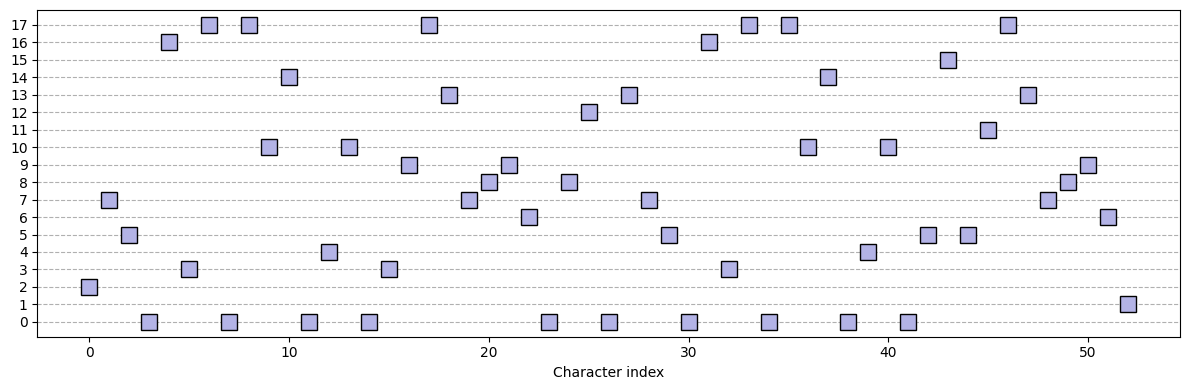

In [37]:
# create a figure
_,ax = plt.subplots(1,figsize=(12,4))

# plot the tokens
ax.plot(tokens,'ks',markersize=12,markerfacecolor=[.7,.7,.9])
ax.set(xlabel='Character index',yticks=range(len(char_vocab)))
ax.grid(linestyle='--',axis='y')

# invisible axis for right-hand-side labels


plt.tight_layout()
plt.savefig('ch2_proj1_part1-tokenscatter.png')
plt.show()